# 🤖 nlptown BERT Fine-Tuning with Class Weights (GPU)
## Amazon Product Reviews — Google Colab Notebook
---
This notebook fine-tunes `nlptown/bert-base-multilingual-uncased-sentiment` on our dataset
applying **class weights** to address the heavy class imbalance (94% positive / 4% neutral / 2% negative).

### Strategy
The nlptown model was originally trained with a 5-class head (1–5 stars).
We **replace the classification head** with a 3-class layer and fine-tune
from the existing BERT encoder weights.

| Step | Detail |
|---|---|
| Base model | `nlptown/bert-base-multilingual-uncased-sentiment` |
| New head | Linear(768 → 3) — replacing the original Linear(768 → 5) |
| Class weights | Inversely proportional to class frequency |
| Optimizer | AdamW, lr = 2e-5 |
| Epochs | 3 |
| Device | Google Colab T4 GPU |

### Why this model + fine-tuning?
- **nlptown pretrained** already achieves 91.53% accuracy (best zero-shot) thanks to domain alignment
- **Neutral F1 = 0.35** and **Negative F1 = 0.58** still have room for improvement
- Fine-tuning with class weights should push minority classes higher while maintaining high accuracy

> ⚙️ Runtime → Change runtime type → **T4 GPU** before running

## 1. 📦 Install & Import Libraries

In [1]:
# Install required libraries (Colab may already have most of these)
!pip install transformers datasets torch scikit-learn -q

import torch
import numpy as np
import pandas as pd
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt

print(f"✅ Libraries loaded")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

✅ Libraries loaded
GPU available: True
Device: Tesla T4


## 2. 📤 Upload Dataset

In [2]:
from google.colab import files

# Upload data/processed/reviews_clean.csv from your local machine
uploaded = files.upload()

Saving reviews_clean.csv to reviews_clean.csv


## 3. 📥 Load & Prepare Data

In [3]:
# Load dataset
df = pd.read_csv("reviews_clean.csv")

print(f"Shape: {df.shape}")
print(f"\nSentiment distribution:")
print(df["sentiment"].value_counts())

# Map string labels to integers
label2id = {"positive": 0, "neutral": 1, "negative": 2}
id2label = {0: "positive", 1: "neutral", 2: "negative"}

df["label"] = df["sentiment"].map(label2id)

# Stratified split preserves class proportions in both sets
df_train, df_test = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["label"]
)

print(f"\nTrain: {len(df_train)} | Test: {len(df_test)}")
print(f"\nTest class distribution:")
print(df_test["sentiment"].value_counts())

Shape: (4805, 11)

Sentiment distribution:
sentiment
positive    4506
neutral      191
negative     108
Name: count, dtype: int64

Train: 4084 | Test: 721

Test class distribution:
sentiment
positive    676
neutral      29
negative     16
Name: count, dtype: int64


### 3.1 ✂️ Create Validation Set
A validation split (~10% of total) lets us monitor overfitting epoch-by-epoch
and save the checkpoint with the lowest validation loss.

In [4]:
# ~12% of train ≈ 10% of total data
df_train, df_val = train_test_split(
    df_train,
    test_size=0.12,
    random_state=42,
    stratify=df_train["label"]
)

print(f"Train:      {len(df_train)} reviews")
print(f"Validation: {len(df_val)} reviews")
print(f"Test:       {len(df_test)} reviews")

print("\nValidation class distribution:")
print(df_val["sentiment"].value_counts())

Train:      3593 reviews
Validation: 491 reviews
Test:       721 reviews

Validation class distribution:
sentiment
positive    460
neutral      20
negative     11
Name: count, dtype: int64


## 4. ⚖️ Compute Class Weights
Weights are inversely proportional to class frequency.
The model is penalized more for misclassifying `neutral` (4%) and `negative` (2%).

In [5]:
# sklearn computes weights as: n_samples / (n_classes * n_samples_per_class)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=df_train["label"].values
)

print("Class weights:")
for i, weight in enumerate(class_weights):
    print(f"  {id2label[i]:<12} → weight: {weight:.4f}")

# Move to GPU for use inside the training loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

Class weights:
  positive     → weight: 0.3554
  neutral      → weight: 8.4343
  negative     → weight: 14.7860


## 5. 🔤 Tokenize Data
The nlptown tokenizer uses WordPiece (standard BERT tokenizer).
We truncate at 128 tokens — this covers ~95% of our reviews (median length is ~21 words).

In [6]:
MODEL_NAME = "nlptown/bert-base-multilingual-uncased-sentiment"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class ReviewDataset(Dataset):
    """PyTorch Dataset wrapping tokenized Amazon reviews."""

    def __init__(self, texts: list, labels: list, tokenizer, max_length: int):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = ReviewDataset(df_train["review_text"].tolist(), df_train["label"].tolist(), tokenizer, MAX_LENGTH)
val_dataset   = ReviewDataset(df_val["review_text"].tolist(),   df_val["label"].tolist(),   tokenizer, MAX_LENGTH)
test_dataset  = ReviewDataset(df_test["review_text"].tolist(),  df_test["label"].tolist(),  tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"✅ Tokenization complete")
print(f"   Train batches:      {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Test batches:       {len(test_loader)}")

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Tokenization complete
   Train batches:      113
   Validation batches: 16
   Test batches:       23


## 6. 🤗 Load Pretrained Model
We load the nlptown BERT encoder and **replace its 5-class head** with a 3-class one.
`ignore_mismatched_sizes=True` discards the original classification weights (expected)
while keeping all encoder layers (the valuable part).

In [7]:
# num_labels=3 replaces the original 5-class head with a 3-class linear layer
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True  # expected: old head (5) → new head (3)
)

model = model.to(device)
print(f"✅ Model loaded on {device}")
print(f"   Total parameters:     {sum(p.numel() for p in model.parameters()):,}")
print(f"   Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nlptown/bert-base-multilingual-uncased-sentiment
Key               | Status   |                                                                                     
------------------+----------+-------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([5]) vs model:torch.Size([3])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([5, 768]) vs model:torch.Size([3, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Model loaded on cuda
   Total parameters:     167,358,723
   Trainable parameters: 167,358,723


## 7. 🏋️ Fine-Tune the Model
Training loop with:
- **Weighted CrossEntropyLoss** — penalizes minority class mistakes more
- **AdamW** optimizer with weight decay (prevents overfitting)
- **Best checkpoint** saved at lowest validation loss

In [8]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

EPOCHS = 3
best_val_loss = float("inf")
history = []

for epoch in range(EPOCHS):
    # ── Training ─────────────────────────────────────────────
    model.train()
    total_train_loss, train_correct, train_total = 0, 0, 0

    for batch in train_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

    train_acc  = train_correct / train_total
    train_loss = total_train_loss / len(train_loader)

    # ── Validation ───────────────────────────────────────────
    model.eval()
    total_val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)

            total_val_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_acc  = val_correct / val_total
    val_loss = total_val_loss / len(val_loader)

    history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss,
                    "train_acc": train_acc, "val_acc": val_acc})

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # Persist the weights that generalize best to unseen data
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_nlptown_model.pt")
        print("  ✅ Best model saved")

print("\n✅ Fine-tuning complete")

Epoch 1/3
  Train Loss: 0.6496 | Train Acc: 0.8492
  Val   Loss: 0.7068 | Val   Acc: 0.8717
  ✅ Best model saved
Epoch 2/3
  Train Loss: 0.4452 | Train Acc: 0.8859
  Val   Loss: 0.8184 | Val   Acc: 0.9124
Epoch 3/3
  Train Loss: 0.2760 | Train Acc: 0.9173
  Val   Loss: 0.8708 | Val   Acc: 0.9002

✅ Fine-tuning complete


## 7.1 📈 Training Curves
Visualising loss and accuracy per epoch helps detect overfitting early.

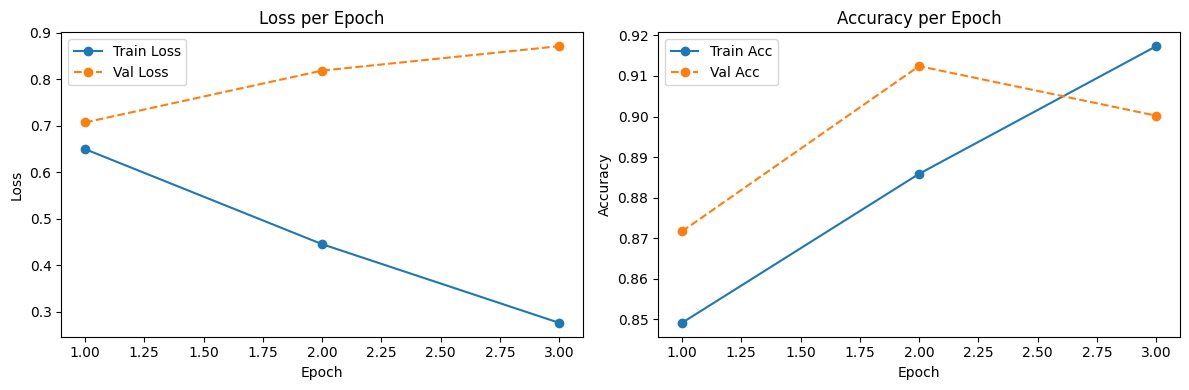

In [9]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="Train Loss")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"],   marker="o", label="Val Loss", linestyle="--")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy curves
axes[1].plot(hist_df["epoch"], hist_df["train_acc"], marker="o", label="Train Acc")
axes[1].plot(hist_df["epoch"], hist_df["val_acc"],   marker="o", label="Val Acc", linestyle="--")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves_nlptown.png", dpi=150)
plt.show()

## 8. 📊 Evaluate on Test Set
We load the best checkpoint (lowest val loss) before evaluating on the held-out test set.

In [10]:
# Reload best checkpoint before final evaluation
model.load_state_dict(torch.load("best_nlptown_model.pt"))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert integer predictions back to string labels
labels_str = ["positive", "neutral", "negative"]
y_true = [id2label[l] for l in all_labels]
y_pred = [id2label[p] for p in all_preds]

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy (test set): {accuracy:.4f} ({accuracy*100:.2f}%)\n")
print("Classification Report:")
print(classification_report(y_true, y_pred, labels=labels_str, target_names=labels_str))

Accuracy (test set): 0.8946 (89.46%)

Classification Report:
              precision    recall  f1-score   support

    positive       0.98      0.92      0.95       676
     neutral       0.22      0.45      0.29        29
    negative       0.40      0.75      0.52        16

    accuracy                           0.89       721
   macro avg       0.53      0.71      0.59       721
weighted avg       0.94      0.89      0.91       721



## 9. 🔲 Confusion Matrix

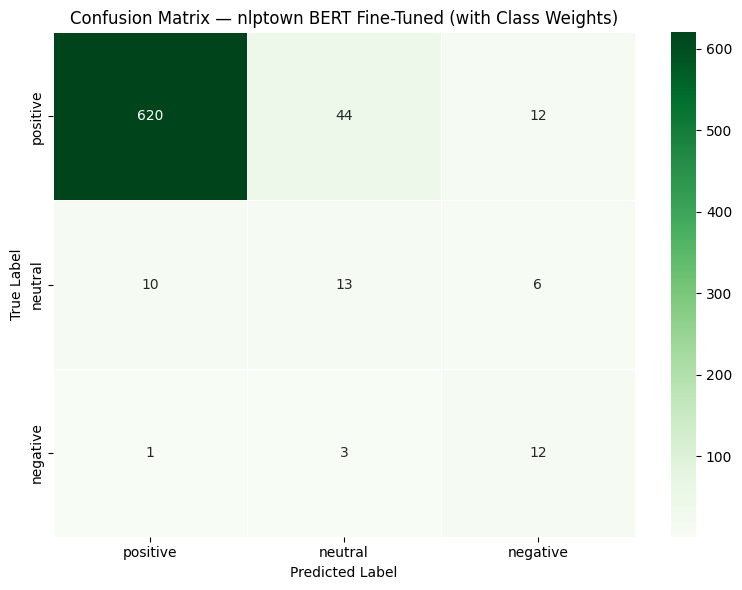

In [11]:
labels_order = ["positive", "neutral", "negative"]
cm = confusion_matrix(y_true, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels_order,
    yticklabels=labels_order,
    linewidths=0.5
)
ax.set_title("Confusion Matrix — nlptown BERT Fine-Tuned (with Class Weights)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix_nlptown_finetuned.png", dpi=150)
plt.show()

## 10. 💾 Save the Fine-Tuned Model
Saves both encoder weights and tokenizer config so the model can be reloaded
later with `AutoModelForSequenceClassification.from_pretrained("./nlptown_finetuned")`.

In [12]:
save_path = "./nlptown_finetuned"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"✅ Model and tokenizer saved to '{save_path}'")

# Uncomment to download the model as a zip
# !zip -r nlptown_finetuned.zip nlptown_finetuned
# from google.colab import files
# files.download("nlptown_finetuned.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model and tokenizer saved to './nlptown_finetuned'


## 11. 📤 Export Full-Dataset Predictions
Run inference on all 4805 reviews and export the results CSV.
Move it to `data/processed/` locally to add it to the comparison table in `02_classification.ipynb`.

In [13]:
model.eval()

all_texts = df["review_text"].fillna("").tolist()
all_preds_full = []

with torch.no_grad():
    for i in range(0, len(all_texts), 32):
        batch_texts = all_texts[i:i + 32]
        encoding = tokenizer(
            batch_texts,
            truncation=True,
            max_length=MAX_LENGTH,
            padding="max_length",
            return_tensors="pt"
        ).to(device)

        outputs = model(**encoding)
        preds   = torch.argmax(outputs.logits, dim=1)
        all_preds_full.extend([id2label[p.item()] for p in preds])

df["predicted_sentiment_nlptown_finetuned"] = all_preds_full

print("Prediction distribution (nlptown fine-tuned, full dataset):")
print(df["predicted_sentiment_nlptown_finetuned"].value_counts())

df.to_csv("reviews_with_predictions_nlptown_finetuned.csv", index=False)
print("\n✅ Saved: reviews_with_predictions_nlptown_finetuned.csv")

Prediction distribution (nlptown fine-tuned, full dataset):
predicted_sentiment_nlptown_finetuned
positive    4212
neutral      360
negative     233
Name: count, dtype: int64

✅ Saved: reviews_with_predictions_nlptown_finetuned.csv


In [14]:
# Download output files to your local machine
from google.colab import files

files.download("reviews_with_predictions_nlptown_finetuned.csv")
files.download("confusion_matrix_nlptown_finetuned.png")
files.download("training_curves_nlptown.png")

print("✅ Downloads started — move files to data/processed/ in VS Code")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloads started — move files to data/processed/ in VS Code


## 12. 📋 Expected Metrics Summary

After fine-tuning, compare these results against the zero-shot baseline in `02_classification.ipynb`:

| Model | Accuracy | F1 neutral | F1 negative | F1 weighted |
|---|---|---|---|---|
| RoBERTa pretrained | 88.82% | 0.16 | 0.45 | 0.91 |
| RoBERTa fine-tuned | 87.83% | 0.36 | **0.73** | 0.91 |
| nlptown pretrained | 91.53% | 0.35 | 0.58 | 0.93 |
| **nlptown fine-tuned** | **?** | **?** | **?** | **?** |

**Hypothesis:** By combining domain alignment (product reviews training data) with class-weighted
fine-tuning, this model should score highest on both Accuracy and F1 weighted,
while also improving minority-class F1 scores above the nlptown zero-shot baseline.

---

### Next steps after downloading the CSV
1. Move `reviews_with_predictions_nlptown_finetuned.csv` → `data/processed/`
2. Open `notebooks/02_classification.ipynb` and run section **14 (Final Comparison)**
   — it will pick up the new file automatically once you add the evaluation block